In [1]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torchvision import datasets
from collections import Counter
import torch.nn as nn
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

generator = torch.Generator()
generator.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [4]:
train_dataset = datasets.ImageFolder('Data/NEU-DET/train/images')

Total classes and images per class

In [5]:
counter = Counter()
class_counts = Counter(train_dataset.targets)

print(f"Total Images: {len(train_dataset)}")
print(f"Image classes: {train_dataset.classes}")

for class_idx, class_name in enumerate(train_dataset.classes):
    print(f"{class_name}: {class_counts[class_idx]}")

Total Images: 1440
Image classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240


Image information: Considering information from `crazing`

In [6]:
image, label = train_dataset[0]
print(f"Image Class: {train_dataset.classes[label]}")
print(f"Image Dimension: {image.size}")

Image Class: crazing
Image Dimension: (200, 200)


<h3>Image Normalization</h3> <br>
Normalization scales pixel values to a common range (such as 0–1 or −1 to 1) before training a CNN. It is important because it:

- Speeds up model convergence.
- Produces more stable gradients during backpropagation.
- Improves the efficiency of optimization algorithms.
- Prevents features with large values from dominating learning.
- Often leads to better accuracy and more stable training.

In [7]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensuring all images in grayscale format i.e B&W
    transforms.Resize((200,200)), # although images are already in dimension 200x200, ensuring it for all
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

`ImageFolder` stores the images data, their classes and all other required information regarding image data

In [8]:
train_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/train/images',
    transform=transform
)

`DataLoader` feeds chunks of image data from every classes in a batch for training a model.

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True,
    generator=generator,
    num_workers=0,
    worker_init_fn=seed_worker,
)

In [10]:
# Validation dataset from folder (separate from train split)
val_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/validation/images',
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    generator=generator
)

<h3>Building a CNN classifier </h3>

In [11]:
class CNN_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(

            # first convolution layer

            nn.Conv2d(
                in_channels=1, # since we have Grayscale image so defining channel size 1
                out_channels=32, # taking 32 kernels of 3x3 size
                kernel_size=3,  # selecting a kernel of 3x3 size
                stride=1, # stride slides scanning 1 step (1 step right, 1 step down and so on)
                padding=1, # padding adds an extra layer/border to prevent missing of important borderline features
                # for now extra padding of values 0 are assigned
            ),

            nn.ReLU(), # Applying ReLU activation to final feature matrix

            nn.MaxPool2d(
                kernel_size=2 , # using maxpool pooling with kernel 2x2
            ),

            # second convolution layer

            nn.Conv2d(
                in_channels=32, # since our input from previous conv layer is 100x100(with 32 kernel values)
                out_channels=64, # defining 64 kernels for conv. layer 2
                stride=1,
                kernel_size=3, # defining 3x3 kernel for conv. layer 2
                padding=1,
            ),

            nn.ReLU(), # again applying relu activation for conv. layer 2 feature matrix

            nn.MaxPool2d(2), # using max pooling with kernel size (2,2)

        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(), # making the pixel in 1 dim

            nn.Linear(              # defining the fully-connected linear layer
                in_features=(50*50*64),
                out_features=128,
                bias=True,
            ),

            nn.ReLU(), # using Relu activation to add non-linearity

            nn.Linear(      # Again full-connected linear layer
            in_features=128,
            out_features=6   # since we have 6 image classes
            ),

        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


<h4>Model Architecture</h4> 

`Convolution Layer 1`

- Input size (`200x200`)
- Padding (1)
- Input size after padding (`202x202`)
- Kernel size (`3x3`)
- Number of kernels (`32`)
- stride (`1`)
- Feature Matrix size (`200x200x32`) 
- `Feature Matrix size = ((n-m+2(p) / stride) x (n-m+2(p) / stride))`
- Final feature size after pooling (`100x100x32`)

`Convolution layer 2`

- Input size (`100x100`)
- Padding (`1`)
- Input size after padding (`102x102`)
- kernel size (`3x3`)
- Number of kernel (`64`)
- stride (`1`)
- Feature Matrix size (`100x100x64`)
- Final size after pooling (`50x50x64`)

`Linearity`

- Fully connected linear layer with `160000` input and `128` output
- Relu activation
- Fully connected linear layer with `128` input and `6` output

<h3>Training Pipeline</h3>

In [12]:
from torch.optim import Adam

In [13]:
model = CNN_classifier().to(device=device)
print(model.parameters)
EPOCHES = 15
criterion = nn.CrossEntropyLoss()   # using multi-class cross entropy loss
optimizer = Adam(params=model.parameters(), lr=0.001)  # taking learning rate 0.001

<bound method Module.parameters of CNN_classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160000, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)>


`Description of training pipeline`

- Taking the epoch value `15`.
- First, Training the model through a batch.
- Calculating the training loss and accuracy at each batch.
- After training through a batch, model is evaluated on shuffled batch with the same parameter it was trained.
- Then, Validation loss for each batch is calculated.
- Above steps are repeated upto `15` epoch.

In [14]:
TRAIN_LOSS = []
TRAIN_ACC = []
VAL_LOSS = []
VAL_ACC = []

for epoch in range (EPOCHES):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:   # Loading a batch of size 32

        # moving the image to GPU
        images = images.to(device)  
        labels = labels.to(device)

        # Reset gradients of all model parameters
        optimizer.zero_grad()

        # forward propagation
        predictions = model(images)

        # computing loss
        loss = criterion(predictions, labels)

        # Note: the model is producing the class of the images i.e label (for our case 0-5)
        # We do not compare the predictions with images (tensor of images)

        loss.backward()

        optimizer.step()    

        running_loss += loss.item() * images.size(0)  
        # we computed the running loss, since CrossEntropy returns mean of the loss, so (loss * batch_size)

        preds = predictions.argmax(dim=1) # predicted labels

        correct += (preds == labels).sum().item() # checking predicted labels == actual labels

        total += labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    TRAIN_LOSS.append(train_loss_epoch)
    TRAIN_ACC.append(train_acc_epoch)

    

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    VAL_LOSS.append(val_loss)
    VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.3860 | Val Loss: 1.4458 | Train Acc: 0.5479 |Val Acc: 0.6278
Epoch  2 | Train Loss: 0.5326 | Val Loss: 0.7282 | Train Acc: 0.8146 |Val Acc: 0.6722
Epoch  3 | Train Loss: 0.2895 | Val Loss: 0.4550 | Train Acc: 0.8972 |Val Acc: 0.8111
Epoch  4 | Train Loss: 0.2556 | Val Loss: 0.7893 | Train Acc: 0.9194 |Val Acc: 0.7500
Epoch  5 | Train Loss: 0.2031 | Val Loss: 0.4711 | Train Acc: 0.9354 |Val Acc: 0.8889
Epoch  6 | Train Loss: 0.1215 | Val Loss: 0.2823 | Train Acc: 0.9611 |Val Acc: 0.8972
Epoch  7 | Train Loss: 0.0937 | Val Loss: 0.2751 | Train Acc: 0.9715 |Val Acc: 0.9111
Epoch  8 | Train Loss: 0.0960 | Val Loss: 0.3298 | Train Acc: 0.9694 |Val Acc: 0.8556
Epoch  9 | Train Loss: 0.1437 | Val Loss: 0.6431 | Train Acc: 0.9521 |Val Acc: 0.7778
Epoch 10 | Train Loss: 0.0889 | Val Loss: 0.3705 | Train Acc: 0.9764 |Val Acc: 0.8556
Epoch 11 | Train Loss: 0.2246 | Val Loss: 0.5065 | Train Acc: 0.9306 |Val Acc: 0.8056
Epoch 12 | Train Loss: 0.1171 | Val Loss: 0.4774 | Tra

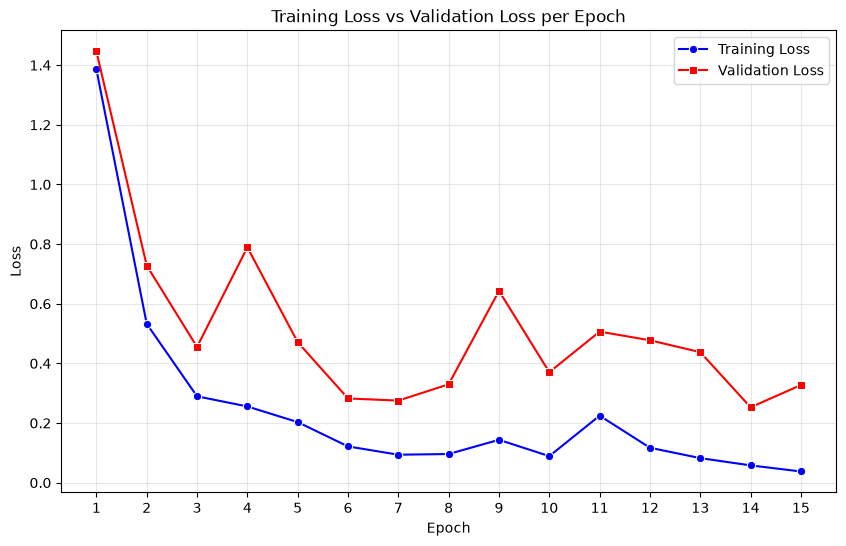

In [15]:
# Training loss vs Validation loss per epoch
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=TRAIN_LOSS, marker="o", label="Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=VAL_LOSS, marker="s", label="Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<b>`Model has overfit after 5 epoch`</b>

In [16]:
from sklearn.metrics import f1_score, classification_report

# Validation F1 score
model.eval()
all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

f1_macro = f1_score(all_val_labels, all_val_preds, average="macro")
f1_weighted = f1_score(all_val_labels, all_val_preds, average="weighted")
f1_micro = f1_score(all_val_labels, all_val_preds, average="micro")

print(f"Validation F1 Score (Macro):    {f1_macro:.4f}")
print(f"Validation F1 Score (Weighted): {f1_weighted:.4f}")
print(f"Validation F1 Score (Micro):    {f1_micro:.4f}")

print("\nClass-wise report:")
print(classification_report(all_val_labels, all_val_preds, target_names=val_dataset.classes, digits=4))

Validation F1 Score (Macro):    0.8977
Validation F1 Score (Weighted): 0.8977
Validation F1 Score (Micro):    0.9028

Class-wise report:
                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        60
      inclusion     0.8500    0.5667    0.6800        60
        patches     1.0000    1.0000    1.0000        60
 pitted_surface     0.7632    0.9667    0.8529        60
rolled-in_scale     0.9836    1.0000    0.9917        60
      scratches     0.8413    0.8833    0.8618        60

       accuracy                         0.9028       360
      macro avg     0.9063    0.9028    0.8977       360
   weighted avg     0.9063    0.9028    0.8977       360



<h3>Data Augmentation</h3>

<b>`Why should we perform data augmentation?`</b>

- Improves model generalization by exposing the model to different variations of the same defect, enabling better performance on unseen production data.
- Simulates real production conditions, such as slight camera misalignment, conveyor belt movement, and variations in defect position or orientation.
- Enhances robustness to environmental changes, including differences in lighting, camera exposure, and minor image distortions commonly encountered in industrial inspection systems.
- Reduces overfitting by preventing the model from memorizing the limited training images and encouraging it to learn meaningful defect characteristics.
- Minimizes the need for collecting large amounts of labeled data, making the defect detection system more practical and cost-effective for industrial applications.

<b>`Why we should not perform data augmentation in validation/test dataset?`</b>

- Ensures fair and unbiased evaluation by testing the model on original, unseen data rather than artificially modified images.
- Maintains a fixed and consistent benchmark, enabling reliable comparison of model performance across different epochs and experiments.
- Prevents data leakage, ensuring that only the training set is used to learn model parameters, while the validation and test sets remain independent for unbiased evaluation.
- Reflects real-world deployment conditions, since validation and test images should represent the actual data the model will encounter in production.

In [17]:
# defining a transformation parameters using torchvision.transforms
aug_train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=1), # ensuring image is grayscale

    transforms.Resize(size= (200,200)),  # resize every image to size 200x200

    transforms.RandomHorizontalFlip(p=0.5), # randomly flip the image horizontally with 50% probability

    transforms.RandomRotation(15), # randomly rotate the image between -15 deg to +15 deg


# Randomly select a crop whose area is between 81% and 100% of the original image.
# Resize that crop to 180 × 180.

    transforms.RandomResizedCrop(  
        size = 200,
        scale = (0.81, 1.0)         
    ),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5], std=[0.5])
]
)


In [18]:
aug_train_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/train/images',
    transform=aug_train_transform
)

In [19]:
aug_train_dataset

Dataset ImageFolder
    Number of datapoints: 1440
    Root location: Data/NEU-DET/train/images
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               RandomResizedCrop(size=(200, 200), scale=(0.81, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )

In [20]:
aug_train_loader = DataLoader(
    dataset=aug_train_dataset,
    shuffle=True,
    num_workers=0,
    generator=generator,
    batch_size=32,
    worker_init_fn=seed_worker,
)

In [21]:
aug_model = CNN_classifier().to(device=device)
aug_optimizer = Adam(aug_model.parameters(), lr=0.001)

Training pipeline for `aug_model`

In [22]:
AUG_TRAIN_LOSS = []
AUG_VAL_LOSS = []
AUG_TRAIN_ACC = []
AUG_VAL_ACC = []

for epoch in range(EPOCHES):
    aug_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for aug_images, aug_labels in aug_train_loader:

        aug_images = aug_images.to(device)
        aug_labels = aug_labels.to(device)

        aug_optimizer.zero_grad()

        aug_prediction = aug_model(aug_images)

        aug_loss = criterion(aug_prediction, aug_labels)

        aug_loss.backward()

        aug_optimizer.step()


        running_loss += aug_loss.item() * aug_images.size(0)  
        

        aug_preds = aug_prediction.argmax(dim=1) # predicted labels

        correct += (aug_preds == aug_labels).sum().item() # checking predicted labels == actual labels

        total += aug_labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    AUG_TRAIN_LOSS.append(train_loss_epoch)
    AUG_TRAIN_ACC.append(train_acc_epoch)

    

    aug_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = aug_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    AUG_VAL_LOSS.append(val_loss)
    AUG_VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.7002 | Val Loss: 1.3324 | Train Acc: 0.4417 |Val Acc: 0.4639
Epoch  2 | Train Loss: 0.8764 | Val Loss: 1.2806 | Train Acc: 0.7021 |Val Acc: 0.4833
Epoch  3 | Train Loss: 0.5566 | Val Loss: 0.7830 | Train Acc: 0.8076 |Val Acc: 0.6472
Epoch  4 | Train Loss: 0.4838 | Val Loss: 0.7762 | Train Acc: 0.8354 |Val Acc: 0.7333
Epoch  5 | Train Loss: 0.4219 | Val Loss: 0.6830 | Train Acc: 0.8528 |Val Acc: 0.7639
Epoch  6 | Train Loss: 0.4046 | Val Loss: 0.8726 | Train Acc: 0.8771 |Val Acc: 0.6417
Epoch  7 | Train Loss: 0.3775 | Val Loss: 0.9454 | Train Acc: 0.8708 |Val Acc: 0.6583
Epoch  8 | Train Loss: 0.2837 | Val Loss: 0.7247 | Train Acc: 0.9083 |Val Acc: 0.6806
Epoch  9 | Train Loss: 0.2333 | Val Loss: 0.4230 | Train Acc: 0.9139 |Val Acc: 0.8694
Epoch 10 | Train Loss: 0.3323 | Val Loss: 2.1552 | Train Acc: 0.8847 |Val Acc: 0.5528
Epoch 11 | Train Loss: 0.2578 | Val Loss: 0.4986 | Train Acc: 0.9187 |Val Acc: 0.7917
Epoch 12 | Train Loss: 0.1748 | Val Loss: 0.7864 | Tra

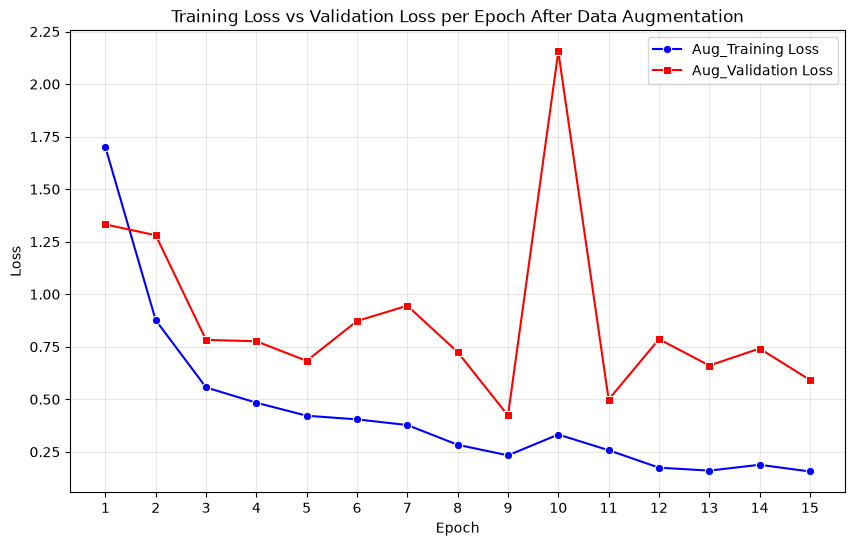

In [23]:
# Training loss vs Validation loss per epoch after data augmentation
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=AUG_TRAIN_LOSS, marker="o", label="Aug_Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=AUG_VAL_LOSS, marker="s", label="Aug_Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch After Data Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<h3>Conclusion After Data Augmentation</h3>

- The validation accuracy increased from `46%` to `78%`
- Where as training accuracy increased from `44%` to `94%`
- It means model is learning on both validation set and training set

<br>

- Previously, The validation accuracy was steady or pleateau after `epoch 5` with accuracy of `88%` - `90%`
- On the other hand, Training accuracy was in range of `55%` to `99%`
- Hence, previously the model was overfitted

`Overfitting has been reduced slightly after data augmentation`

<h3>Batch Normalization</h3>

Concepts learnt about `Batch Normalization`

- Problem: Inputs to deeper layers keep changing (internal covariate shift).
  - `BN`: Normalizes each mini-batch to stabilize input distributions.
- Problem: Training is slow.
  - `BN`: Stabilizes optimization, leading to faster convergence.
- Problem: Activations become too large or too small.
  - `BN`: Keeps activations in a controlled range.
- Problem: Gradients vanish or explode.
  - `BN`: Improves gradient flow through the network.
- Problem: Model is highly sensitive to weight initialization.
  - `BN`: Reduces dependence on careful initialization.
- Problem: Training becomes unstable with high learning rates.
  - `BN`: Makes larger learning rates feasible.
- Problem: Overfitting.
  - `BN`: Provides mild regularization through mini-batch statistics, though dedicated techniques like dropout are still commonly used when stronger regularization is needed.

- <b>Copied the `CNN_Classifier` Model</b>
- Modified the model's architecture by adding `nn.BatchNorm2d` after each convolution layer

In [24]:
class CNN_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(

            # first convolution layer

            nn.Conv2d(
                in_channels=1, # since we have Grayscale image so defining channel size 1
                out_channels=32, # taking 32 kernels of 3x3 size
                kernel_size=3,  # selecting a kernel of 3x3 size
                stride=1, # stride slides scanning 1 step (1 step right, 1 step down and so on)
                padding=1, # padding adds an extra layer/border to prevent missing of important borderline features
                # for now extra padding of values 0 are assigned
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(), # Applying ReLU activation to final feature matrix

            nn.MaxPool2d(
                kernel_size=2 , # using maxpool pooling with kernel 2x2
            ),

            # second convolution layer

            nn.Conv2d(
                in_channels=32, # since our input from previous conv layer is 100x100(with 32 kernel values)
                out_channels=64, # defining 64 kernels for conv. layer 2
                stride=1,
                kernel_size=3, # defining 3x3 kernel for conv. layer 2
                padding=1,
            ),

            nn.BatchNorm2d(64),  # Batch Normalization 

            nn.ReLU(), # again applying relu activation for conv. layer 2 feature matrix

            nn.MaxPool2d(2), # using max pooling with kernel size (2,2)

        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(), # making the pixel in 1 dim

            nn.Linear(              # defining the fully-connected linear layer
                in_features=(50*50*64),
                out_features=128,
                bias=True,
            ),

            nn.ReLU(), # using Relu activation to add non-linearity

            nn.BatchNorm1d(128),

            nn.Linear(      # Again full-connected linear layer
            in_features=128,
            out_features=6   # since we have 6 image classes
            ),

        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Training pipeline after applying batch normalization

In [25]:
BN_model = CNN_classifier().to(device=device)
BN_optimizer = Adam(BN_model.parameters(), lr=0.001)

In [26]:
BN_TRAIN_LOSS = []
BN_VAL_LOSS = []
BN_TRAIN_ACC = []
BN_VAL_ACC = []

for epoch in range(EPOCHES):
    BN_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for BN_images, BN_labels in aug_train_loader:

        BN_images = BN_images.to(device)
        BN_labels = BN_labels.to(device)

        BN_optimizer.zero_grad()

        BN_prediction = BN_model(BN_images)

        BN_loss = criterion(BN_prediction, BN_labels)

        BN_loss.backward()

        BN_optimizer.step()


        running_loss += BN_loss.item() * BN_images.size(0)  
        

        BN_preds = BN_prediction.argmax(dim=1) # predicted labels

        correct += (BN_preds == BN_labels).sum().item() # checking predicted labels == actual labels

        total += BN_labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    BN_TRAIN_LOSS.append(train_loss_epoch)
    BN_TRAIN_ACC.append(train_acc_epoch)

    

    BN_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = BN_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    BN_VAL_LOSS.append(val_loss)
    BN_VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.0001 | Val Loss: 1.8637 | Train Acc: 0.6396 |Val Acc: 0.2583
Epoch  2 | Train Loss: 0.6179 | Val Loss: 1.7071 | Train Acc: 0.8049 |Val Acc: 0.3944
Epoch  3 | Train Loss: 0.5165 | Val Loss: 2.7794 | Train Acc: 0.8326 |Val Acc: 0.3444
Epoch  4 | Train Loss: 0.6343 | Val Loss: 0.9809 | Train Acc: 0.7917 |Val Acc: 0.5444
Epoch  5 | Train Loss: 0.4319 | Val Loss: 1.3777 | Train Acc: 0.8562 |Val Acc: 0.4250
Epoch  6 | Train Loss: 0.3872 | Val Loss: 0.8967 | Train Acc: 0.8806 |Val Acc: 0.6139
Epoch  7 | Train Loss: 0.3495 | Val Loss: 1.0198 | Train Acc: 0.8938 |Val Acc: 0.6139
Epoch  8 | Train Loss: 0.3246 | Val Loss: 0.7331 | Train Acc: 0.8979 |Val Acc: 0.6750
Epoch  9 | Train Loss: 0.3188 | Val Loss: 0.6954 | Train Acc: 0.9007 |Val Acc: 0.7083
Epoch 10 | Train Loss: 0.3324 | Val Loss: 0.5644 | Train Acc: 0.8833 |Val Acc: 0.7778
Epoch 11 | Train Loss: 0.2947 | Val Loss: 0.5499 | Train Acc: 0.9062 |Val Acc: 0.7694
Epoch 12 | Train Loss: 0.2968 | Val Loss: 0.5551 | Tra

`conclusion`: Model is improving after adding batch normalization

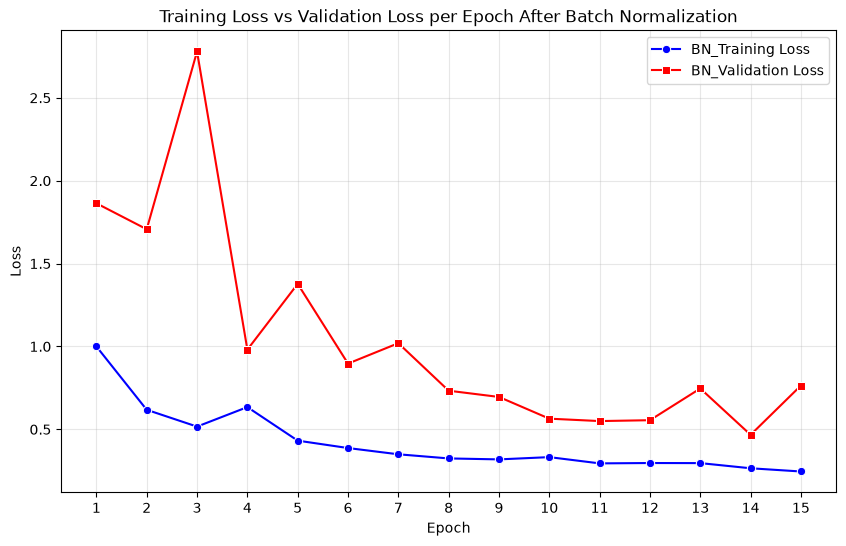

In [27]:
# Training loss vs Validation loss per epoch after data augmentation with batch normalization
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=BN_TRAIN_LOSS, marker="o", label="BN_Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=BN_VAL_LOSS, marker="s", label="BN_Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch After Batch Normalization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Using `nn.Dropout` keeping probability `p=0.4`

In [28]:
DRBN_model = CNN_classifier().to(device=device)
DRBN_optimizer = Adam(DRBN_model.parameters(), lr=0.001)

In [29]:
DRBN_model.named_parameters

<bound method Module.named_parameters of CNN_classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160000, out_features=128, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)>

In [30]:
class CNN_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(

            # first convolution layer

            nn.Conv2d(
                in_channels=1, # since we have Grayscale image so defining channel size 1
                out_channels=32, # taking 32 kernels of 3x3 size
                kernel_size=3,  # selecting a kernel of 3x3 size
                stride=1, # stride slides scanning 1 step (1 step right, 1 step down and so on)
                padding=1, # padding adds an extra layer/border to prevent missing of important borderline features
                # for now extra padding of values 0 are assigned
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(), # Applying ReLU activation to final feature matrix

            nn.Dropout2d(p=0.2),  # dropping out neurons after activation keeping probability 50%

            nn.MaxPool2d(
                kernel_size=2 , # using maxpool pooling with kernel 2x2
            ),

            # second convolution layer

            nn.Conv2d(
                in_channels=32, # since our input from previous conv layer is 100x100(with 32 kernel values)
                out_channels=64, # defining 64 kernels for conv. layer 2
                stride=1,
                kernel_size=3, # defining 3x3 kernel for conv. layer 2
                padding=1,
            ),

            nn.BatchNorm2d(64),  # Batch Normalization 

            nn.ReLU(), # again applying relu activation for conv. layer 2 feature matrix

            nn.Dropout2d(p=0.2),  # dropping out neurons after activation keeping probability 50%


            nn.MaxPool2d(2), # using max pooling with kernel size (2,2)

        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(), # making the pixel in 1 dim

            nn.Linear(              # defining the fully-connected linear layer
                in_features=(50*50*64),
                out_features=128,
                bias=True,
            ),

            nn.BatchNorm1d(128),  # Batch Normalization 

            nn.ReLU(), # using Relu activation to add non-linearity

            nn.Dropout(p=0.4),

            nn.Linear(      # Again full-connected linear layer
            in_features=128,
            out_features=6   # since we have 6 image classes
            ),

        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
# Training pipeline for model after dropout and batch normalization

DRBN_TRAIN_LOSS = []
DRBN_VAL_LOSS = []
DRBN_TRAIN_ACC = []
DRBN_VAL_ACC = []

for epoch in range(EPOCHES):
    DRBN_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for DRBN_images, DRBN_labels in aug_train_loader:

        DRBN_images = DRBN_images.to(device)
        DRBN_labels = DRBN_labels.to(device)

        DRBN_optimizer.zero_grad()

        DRBN_prediction = DRBN_model(DRBN_images)

        DRBN_loss = criterion(DRBN_prediction, DRBN_labels)

        DRBN_loss.backward()

        DRBN_optimizer.step()


        running_loss += DRBN_loss.item() * DRBN_images.size(0)  
        

        DRBN_preds = DRBN_prediction.argmax(dim=1) # predicted labels

        correct += (DRBN_preds == DRBN_labels).sum().item() # checking predicted labels == actual labels

        total += DRBN_labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    DRBN_TRAIN_LOSS.append(train_loss_epoch)
    DRBN_TRAIN_ACC.append(train_acc_epoch)

    

    DRBN_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = DRBN_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    DRBN_VAL_LOSS.append(val_loss)
    DRBN_VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 0.9332 | Val Loss: 1.2816 | Train Acc: 0.6868 |Val Acc: 0.5278
Epoch  2 | Train Loss: 0.6294 | Val Loss: 1.0510 | Train Acc: 0.7958 |Val Acc: 0.5083
Epoch  3 | Train Loss: 0.5063 | Val Loss: 1.1911 | Train Acc: 0.8424 |Val Acc: 0.5417
Epoch  4 | Train Loss: 0.4264 | Val Loss: 0.8669 | Train Acc: 0.8722 |Val Acc: 0.6528
Epoch  5 | Train Loss: 0.3681 | Val Loss: 0.7895 | Train Acc: 0.8819 |Val Acc: 0.6861
Epoch  6 | Train Loss: 0.3531 | Val Loss: 0.7824 | Train Acc: 0.8764 |Val Acc: 0.7028
Epoch  7 | Train Loss: 0.2984 | Val Loss: 0.8130 | Train Acc: 0.9139 |Val Acc: 0.6056
Epoch  8 | Train Loss: 0.2732 | Val Loss: 0.9294 | Train Acc: 0.9201 |Val Acc: 0.6111
Epoch  9 | Train Loss: 0.2988 | Val Loss: 1.2895 | Train Acc: 0.9083 |Val Acc: 0.5556
Epoch 10 | Train Loss: 0.2774 | Val Loss: 0.8176 | Train Acc: 0.9160 |Val Acc: 0.7417
Epoch 11 | Train Loss: 0.2711 | Val Loss: 0.7091 | Train Acc: 0.9167 |Val Acc: 0.7222
Epoch 12 | Train Loss: 0.2626 | Val Loss: 0.5845 | Tra

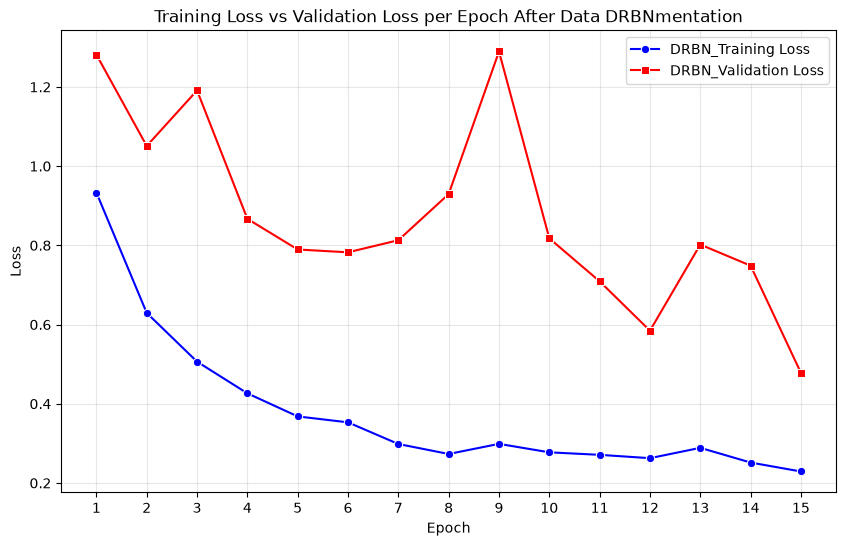

In [31]:
# Training loss vs Validation loss per epoch after data augmentation, batch normalization & dropout
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=DRBN_TRAIN_LOSS, marker="o", label="DRBN_Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=DRBN_VAL_LOSS, marker="s", label="DRBN_Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch After Data DRBNmentation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

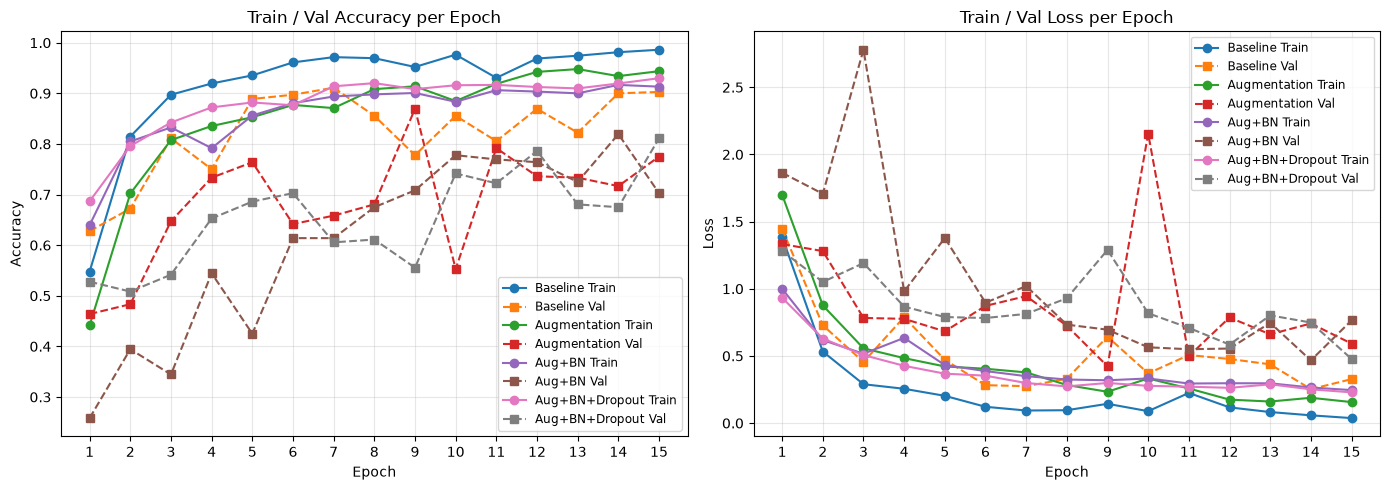

Baseline: final (train_acc=0.9861, val_acc=0.9028, train_loss=0.0374, val_loss=0.3273) | best_val_acc=0.9111 @epoch 7
Augmentation: final (train_acc=0.9437, val_acc=0.7750, train_loss=0.1565, val_loss=0.5921) | best_val_acc=0.8694 @epoch 9
Aug+BN: final (train_acc=0.9132, val_acc=0.7028, train_loss=0.2457, val_loss=0.7643) | best_val_acc=0.8194 @epoch 14
Aug+BN+Dropout: final (train_acc=0.9299, val_acc=0.8111, train_loss=0.2290, val_loss=0.4779) | best_val_acc=0.8111 @epoch 15


In [32]:
# Comparison of baseline, data augmentation, augmentation+BN, augmentation+BN+Dropout

models = {
    "Baseline": {"train_acc": TRAIN_ACC, "val_acc": VAL_ACC, "train_loss": TRAIN_LOSS, "val_loss": VAL_LOSS},
    "Augmentation": {"train_acc": AUG_TRAIN_ACC, "val_acc": AUG_VAL_ACC, "train_loss": AUG_TRAIN_LOSS, "val_loss": AUG_VAL_LOSS},
    "Aug+BN": {"train_acc": BN_TRAIN_ACC, "val_acc": BN_VAL_ACC, "train_loss": BN_TRAIN_LOSS, "val_loss": BN_VAL_LOSS},
    "Aug+BN+Dropout": {"train_acc": DRBN_TRAIN_ACC, "val_acc": DRBN_VAL_ACC, "train_loss": DRBN_TRAIN_LOSS, "val_loss": DRBN_VAL_LOSS},
}

epochs_axis = list(range(1, EPOCHES + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
for name, v in models.items():
    axes[0].plot(epochs_axis, v["train_acc"], marker="o", label=f"{name} Train")
    axes[0].plot(epochs_axis, v["val_acc"], marker="s", linestyle="--", label=f"{name} Val")
axes[0].set_title("Train / Val Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epochs_axis)
axes[0].legend(fontsize="small")
axes[0].grid(alpha=0.3)

# Loss plot
for name, v in models.items():
    axes[1].plot(epochs_axis, v["train_loss"], marker="o", label=f"{name} Train")
    axes[1].plot(epochs_axis, v["val_loss"], marker="s", linestyle="--", label=f"{name} Val")
axes[1].set_title("Train / Val Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(epochs_axis)
axes[1].legend(fontsize="small")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table (final and best validation)
for name, v in models.items():
    final_train_acc = v["train_acc"][-1]
    final_val_acc = v["val_acc"][-1]
    final_train_loss = v["train_loss"][-1]
    final_val_loss = v["val_loss"][-1]
    best_val_acc = max(v["val_acc"])
    best_epoch = v["val_acc"].index(best_val_acc) + 1
    print(f"{name}: final (train_acc={final_train_acc:.4f}, val_acc={final_val_acc:.4f}, train_loss={final_train_loss:.4f}, val_loss={final_val_loss:.4f}) | best_val_acc={best_val_acc:.4f} @epoch {best_epoch}")

<h3>Conclusion</h3>

I would choose data augmentation because it directly improves the model's ability to generalize to unseen manufacturing images. Manufacturing environments naturally introduce variations such as changes in illumination, orientation, scale, and positioning. By exposing the model to these variations during training, data augmentation reduces overfitting and improves robustness. In my experiments, the augmentation-only model achieved the most consistent validation performance with a smaller gap between training and validation accuracy, indicating better generalization than the baseline, Batch Normalization, or Batch Normalization with Dropout.

<h3>Hyperparameter Tuning</h3>

In [ ]:
from itertools import product

In [43]:
param_grid = {
    "lr": [0.001, 0.0006],
    "batch_size": [16, 32],
    "optimizer": ["Adam", "SGD"],
}

In [42]:
keys = param_grid.keys()

for values in product(*param_grid.values()):

    params = dict(zip(keys, values))

    print(params)

{'lr': 0.001, 'batch_size': 16, 'optimizer': 'Adam', 'dropout': 0.3}
{'lr': 0.001, 'batch_size': 16, 'optimizer': 'Adam', 'dropout': 0.5}
{'lr': 0.001, 'batch_size': 16, 'optimizer': 'SGD', 'dropout': 0.3}
{'lr': 0.001, 'batch_size': 16, 'optimizer': 'SGD', 'dropout': 0.5}
{'lr': 0.001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3}
{'lr': 0.001, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.5}
{'lr': 0.001, 'batch_size': 32, 'optimizer': 'SGD', 'dropout': 0.3}
{'lr': 0.001, 'batch_size': 32, 'optimizer': 'SGD', 'dropout': 0.5}
{'lr': 0.0006, 'batch_size': 16, 'optimizer': 'Adam', 'dropout': 0.3}
{'lr': 0.0006, 'batch_size': 16, 'optimizer': 'Adam', 'dropout': 0.5}
{'lr': 0.0006, 'batch_size': 16, 'optimizer': 'SGD', 'dropout': 0.3}
{'lr': 0.0006, 'batch_size': 16, 'optimizer': 'SGD', 'dropout': 0.5}
{'lr': 0.0006, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.3}
{'lr': 0.0006, 'batch_size': 32, 'optimizer': 'Adam', 'dropout': 0.5}
{'lr': 0.0006, 'batch_size': 32, '

In [48]:
best_acc = 0
best_params = None

for combination in product(*param_grid.values()):

    params = dict(zip(param_grid.keys(), combination))

    # New model
    final_model = CNN_classifier().to(device)

    # DataLoader
    aug_train_loader = DataLoader(
    dataset=aug_train_dataset,
    shuffle=True,
    num_workers=0,
    generator=generator,
    batch_size=params["batch_size"],
    worker_init_fn=seed_worker,
    )

    # Optimizer
    if params["optimizer"] == "Adam":
        final_optimizer = torch.optim.Adam(
            final_model.parameters(),
            lr=params["lr"]
        )
    else:
        final_optimizer = torch.optim.SGD(
            final_model.parameters(),
            lr=params["lr"],
            momentum=0.9
        )

    # Train for N epochs
    FINAL_TRAIN_LOSS = []
    FINAL_VAL_LOSS = []
    FINAL_TRAIN_ACC = []
    FINAL_VAL_ACC = []

    for epoch in range(EPOCHES):
        final_model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for final_images, final_labels in aug_train_loader:

            final_images = final_images.to(device)
            final_labels = final_labels.to(device)

            final_optimizer.zero_grad()

            final_prediction = final_model(final_images)

            final_loss = criterion(final_prediction, final_labels)

            final_loss.backward()

            final_optimizer.step()


            running_loss += final_loss.item() * final_images.size(0)  
            

            final_preds = final_prediction.argmax(dim=1) # predicted labels

            correct += (final_preds == final_labels).sum().item() # checking predicted labels == actual labels

            total += final_labels.size(0) 

        train_loss_epoch = running_loss / total  # training loss per epoch
        train_acc_epoch = correct / total  # training accuracy per epoch

        FINAL_TRAIN_LOSS.append(train_loss_epoch)
        FINAL_TRAIN_ACC.append(train_acc_epoch)

        

        final_model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = final_model(images)

                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(dim=1)

                val_correct += (preds == labels).sum().item()

                val_total += labels.size(0)

        val_loss = running_val_loss / val_total
        val_acc = val_correct / val_total

        FINAL_VAL_LOSS.append(val_loss)
        FINAL_VAL_ACC.append(val_acc)


        print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss_epoch:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc_epoch:.4f} |"
        f"Val Acc: {val_acc:.4f}"
        )

    # Save best
    if val_acc > best_acc:
        best_acc = val_acc
        best_params = params.copy()

print(best_params, best_acc)

Epoch  1 | Train Loss: 1.1489 | Val Loss: 1.0012 | Train Acc: 0.5493 |Val Acc: 0.6083
Epoch  2 | Train Loss: 0.9175 | Val Loss: 0.9926 | Train Acc: 0.6299 |Val Acc: 0.5944
Epoch  3 | Train Loss: 0.8295 | Val Loss: 1.1283 | Train Acc: 0.6771 |Val Acc: 0.5278
Epoch  4 | Train Loss: 0.7577 | Val Loss: 1.0123 | Train Acc: 0.7090 |Val Acc: 0.5361
Epoch  5 | Train Loss: 0.6856 | Val Loss: 1.0228 | Train Acc: 0.7493 |Val Acc: 0.5806
Epoch  6 | Train Loss: 0.6485 | Val Loss: 1.1845 | Train Acc: 0.7458 |Val Acc: 0.5306
Epoch  7 | Train Loss: 0.6354 | Val Loss: 0.8010 | Train Acc: 0.7764 |Val Acc: 0.6639
Epoch  8 | Train Loss: 0.5855 | Val Loss: 1.0314 | Train Acc: 0.7931 |Val Acc: 0.5528
Epoch  9 | Train Loss: 0.5775 | Val Loss: 0.7132 | Train Acc: 0.7819 |Val Acc: 0.7167
Epoch 10 | Train Loss: 0.5541 | Val Loss: 0.9021 | Train Acc: 0.8028 |Val Acc: 0.7056
Epoch 11 | Train Loss: 0.5271 | Val Loss: 0.8199 | Train Acc: 0.7986 |Val Acc: 0.6806
Epoch 12 | Train Loss: 0.5327 | Val Loss: 1.2502 | Tra

`Conclusion`: Hence, we got the best parameter as:

- learning rate: 0.006
- batch size: 16
- optimizer: Adam